In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('sample_50000.csv')
df.head()

,shipment_id,carrier,origin_port,destination_port,transport_mode,status,goods_category,currency,created_date,eta_date,...,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,temperature_c,priority_level,insurance_required
0,SHP-103243220,Hapag-Lloyd,Guangzhou,Felixstowe,air,On_Schedule,Machinery,SGD,2022-03-15,2022-03-17,...,43376.98,4,4,0.0,0.3746,0.2212,0.1861,NaN,3,True
1,SHP-100992986,ZIM,Antwerp,Savannah,sea,In_Transit,Pharmaceuticals,EUR,2023-11-01,2023-11-11,...,86.78,20,5,0.0,0.1461,0.4391,0.5019,NaN,2,True
2,SHP-100155396,HMM,Sydney,Barcelona,sea,At_Port,Automotive,EUR,2024-08-25,2024-09-06,...,1191.33,21,1,0.0,0.0250,0.2681,0.2048,-0.0,1,True
3,SHP-101216903,FedEx,Rotterdam,Piraeus,sea,Customs_Hold,Food_Beverage,USD,2022-10-08,2022-11-05,...,49996.43,1,4,0.0,0.6754,0.0185,0.2274,NaN,1,True
4,SHP-103930952,DB_Schenker,Jebel_Ali,Rotterdam,sea,On_Schedule,Raw_Materials,AED,2023-05-06,2023-05-26,...,6090.75,6,1,0.0,0.1988,0.1598,0.5593,NaN,1,True


In [5]:
df.isnull().sum() # проверяем пропуски

shipment_id               0
carrier                   0
origin_port               0
destination_port          0
transport_mode            0
status                    0
goods_category            0
currency                  0
created_date              0
eta_date                  0
transit_hours             0
distance_km               0
weight_kg                 0
volume_m3                 0
value_usd                 0
freight_cost_usd          0
num_containers            0
num_stops                 0
delay_hours               0
risk_score                0
weather_severity          0
port_congestion           0
temperature_c         35107
priority_level            0
insurance_required        0
dtype: int64

In [6]:
df.isnull().mean()*100 # проверяем пропуски в %

shipment_id            0.000
carrier                0.000
origin_port            0.000
destination_port       0.000
transport_mode         0.000
status                 0.000
goods_category         0.000
currency               0.000
created_date           0.000
eta_date               0.000
transit_hours          0.000
distance_km            0.000
weight_kg              0.000
volume_m3              0.000
value_usd              0.000
freight_cost_usd       0.000
num_containers         0.000
num_stops              0.000
delay_hours            0.000
risk_score             0.000
weather_severity       0.000
port_congestion        0.000
temperature_c         70.214
priority_level         0.000
insurance_required     0.000
dtype: float64

In [7]:
df.info() # оценка структуры файла

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   shipment_id         50000 non-null  str    
 1   carrier             50000 non-null  str    
 2   origin_port         50000 non-null  str    
 3   destination_port    50000 non-null  str    
 4   transport_mode      50000 non-null  str    
 5   status              50000 non-null  str    
 6   goods_category      50000 non-null  str    
 7   currency            50000 non-null  str    
 8   created_date        50000 non-null  str    
 9   eta_date            50000 non-null  str    
 10  transit_hours       50000 non-null  float64
 11  distance_km         50000 non-null  float64
 12  weight_kg           50000 non-null  float64
 13  volume_m3           50000 non-null  float64
 14  value_usd           50000 non-null  float64
 15  freight_cost_usd    50000 non-null  float64
 16  num_containers 

In [8]:
df = df.drop(columns=['temperature_c']) # слишком много пропусков+ сгенерированные данные исказят= удаляем полностью

In [9]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool'])

In [10]:
correlation_matrix = numeric_df.corr()

In [11]:
numeric_df.corr()

,transit_hours,distance_km,weight_kg,volume_m3,value_usd,freight_cost_usd,num_containers,num_stops,delay_hours,risk_score,weather_severity,port_congestion,priority_level,insurance_required
transit_hours,1.000000,0.318583,-0.006323,-0.002949,0.001141,0.001950,0.004727,-0.009497,0.004422,-0.001529,0.002466,0.003719,-0.000410,-0.000120
distance_km,0.318583,1.000000,-0.001863,-0.001495,-0.006103,-0.006319,-0.000176,0.002042,0.004710,-0.003391,-0.003159,0.003467,0.005240,0.001550
weight_kg,-0.006323,-0.001863,1.000000,0.915283,-0.000443,-0.003940,0.008513,-0.002448,0.002552,-0.002571,0.008508,-0.001634,-0.001260,0.002306
volume_m3,-0.002949,-0.001495,0.915283,1.000000,-0.000671,-0.003816,0.008552,0.000478,0.002897,-0.003479,0.010014,-0.000158,-0.001141,0.002278
value_usd,0.001141,-0.006103,-0.000443,-0.000671,1.000000,0.879206,-0.001515,0.006385,-0.000997,-0.000872,0.003127,0.000597,-0.004446,0.005523
freight_cost_usd,0.001950,-0.006319,-0.003940,-0.003816,0.879206,1.000000,-0.000144,0.005436,-0.002862,-0.000209,0.001363,-0.003733,-0.004896,0.005349
num_containers,0.004727,-0.000176,0.008513,0.008552,-0.001515,-0.000144,1.000000,-0.006498,0.005830,-0.003707,0.001528,0.002428,0.000909,0.003698
num_stops,-0.009497,0.002042,-0.002448,0.000478,0.006385,0.005436,-0.006498,1.000000,0.001336,0.003368,-0.001735,0.004679,0.001097,0.007846
delay_hours,0.004422,0.004710,0.002552,0.002897,-0.000997,-0.002862,0.005830,0.001336,1.000000,0.000648,0.003728,-0.000005,0.005803,-0.000574
risk_score,-0.001529,-0.003391,-0.002571,-0.003479,-0.000872,-0.000209,-0.003707,0.003368,0.000648,1.000000,0.004863,-0.001372,0.007580,-0.000918


In [12]:
delay_correlation = correlation_matrix['delay_hours'].sort_values(ascending=False)

In [13]:
print("Корреляция числовых признаков с задержкой (delay_hours):")
print(delay_correlation)

Корреляция числовых признаков с задержкой (delay_hours):
delay_hours           1.000000
num_containers        0.005830
priority_level        0.005803
distance_km           0.004710
transit_hours         0.004422
weather_severity      0.003728
volume_m3             0.002897
weight_kg             0.002552
num_stops             0.001336
risk_score            0.000648
port_congestion      -0.000005
insurance_required   -0.000574
value_usd            -0.000997
freight_cost_usd     -0.002862
Name: delay_hours, dtype: float64


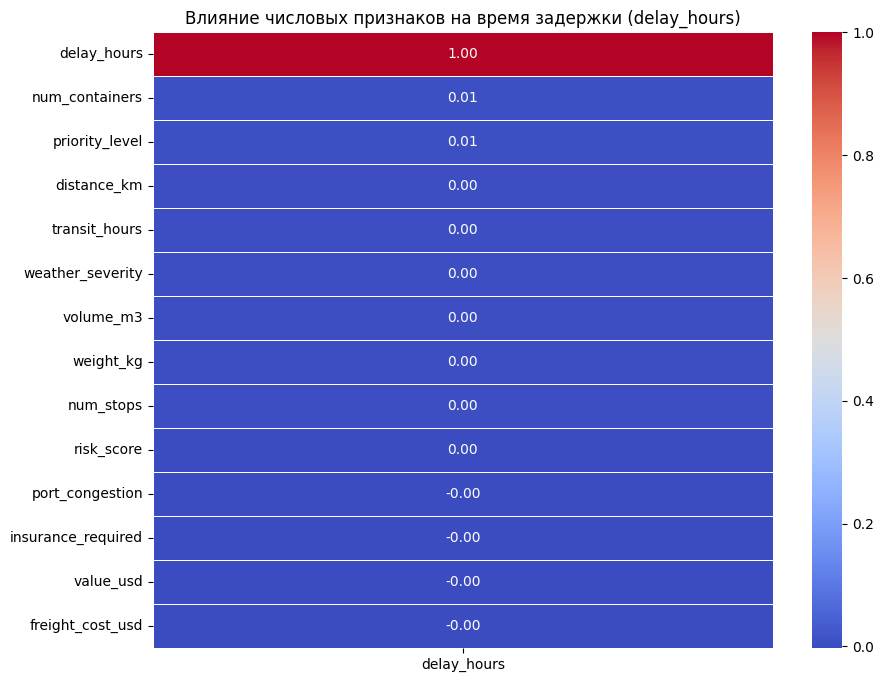

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# Строим тепловую карту для топ-факторов, связанных с задержкой
sns.heatmap(correlation_matrix[['delay_hours']].sort_values(by='delay_hours', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Влияние числовых признаков на время задержки (delay_hours)')
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_8792\3613921475.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_ports, x='origin_port', y='delay_hours', palette='coolwarm')


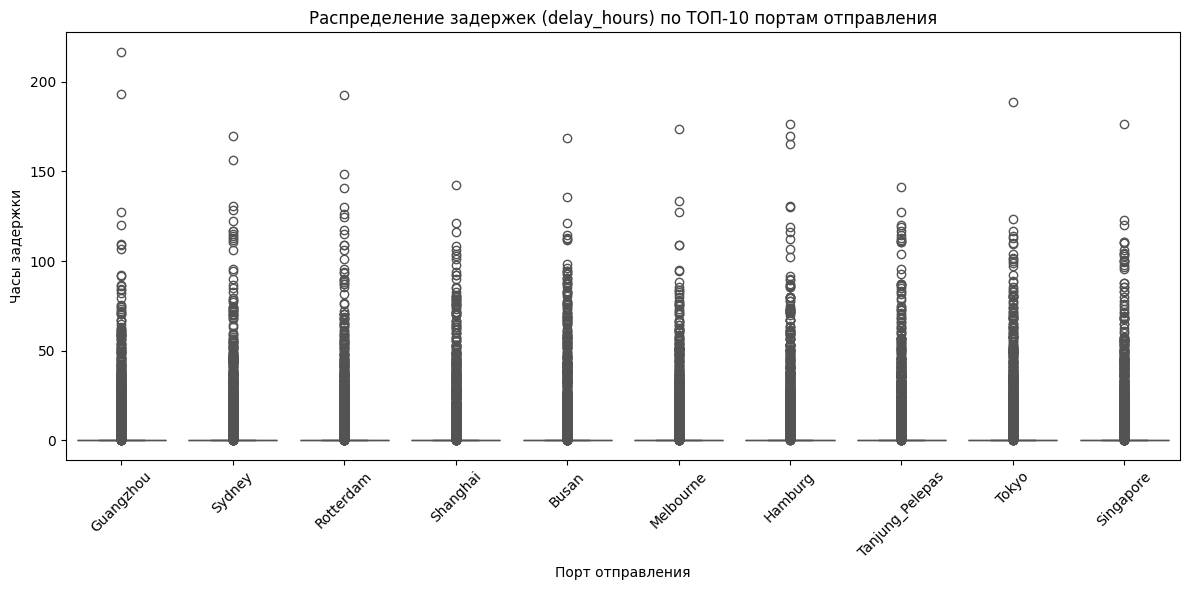

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Находим топ-10 портов по количеству записей
top_ports = df['origin_port'].value_counts().head(10).index
df_top_ports = df[df['origin_port'].isin(top_ports)]

# 2. Настраиваем крупный размер графика
plt.figure(figsize=(12, 6))

# 3. Строим боксплот
sns.boxplot(data=df_top_ports, x='origin_port', y='delay_hours', palette='coolwarm')

# 4. Поворачиваем названия портов на 45 градусов, чтобы они не слипались
plt.xticks(rotation=45)

# 5. Добавляем понятные подписи
plt.title('Распределение задержек (delay_hours) по ТОП-10 портам отправления')
plt.xlabel('Порт отправления')
plt.ylabel('Часы задержки')

plt.tight_layout()
plt.show()

C:\Users\jenny\AppData\Local\Temp\ipykernel_8792\1462278271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='transport_mode', y='delay_hours', palette='Set2')


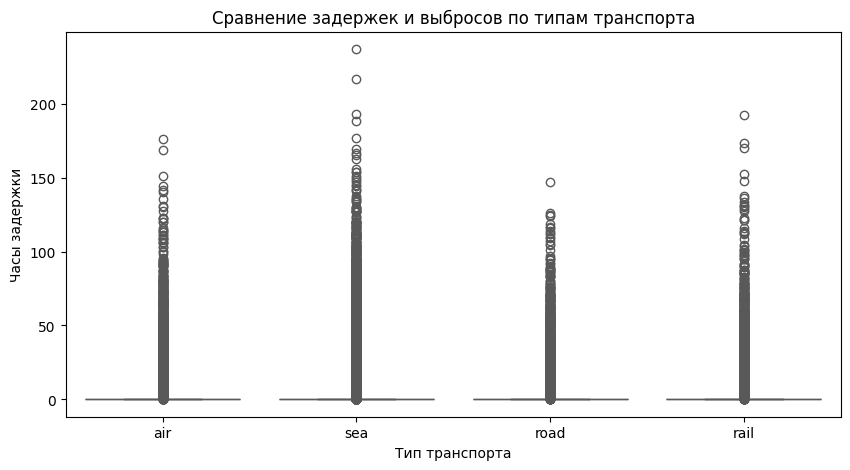

In [17]:
plt.figure(figsize=(10, 5))

# Строим боксплот по типам транспорта
sns.boxplot(data=df, x='transport_mode', y='delay_hours', palette='Set2')

plt.title('Сравнение задержек и выбросов по типам транспорта')
plt.xlabel('Тип транспорта')
plt.ylabel('Часы задержки')

plt.show()

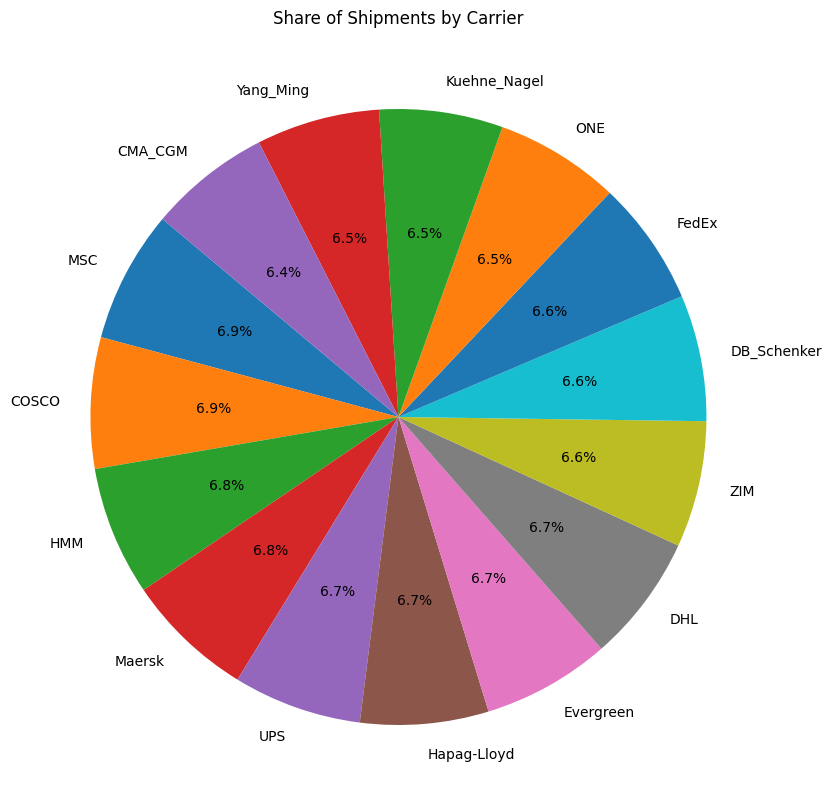

In [18]:
# доля рынка по перевозчикам
carrier_counts=df['carrier'].value_counts()
plt.figure(figsize=(10,10))
plt.pie(carrier_counts, labels=carrier_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Share of Shipments by Carrier')
plt.show()

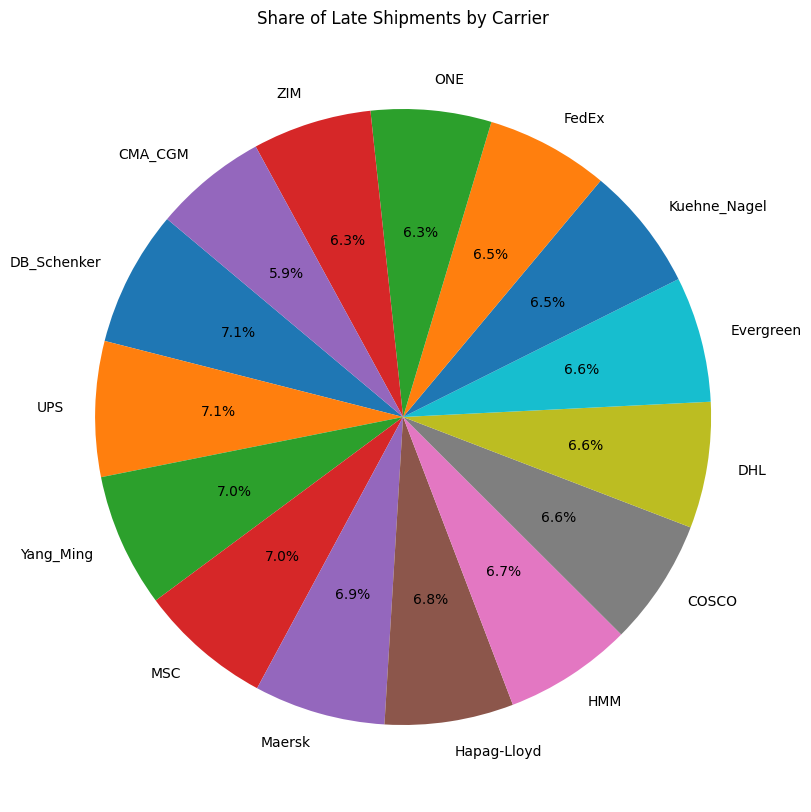

In [19]:
# доля задержек каждого перевозчика
late_df=df[df['delay_hours']>0]
late_carrier_counts=late_df['carrier'].value_counts()
plt.figure(figsize=(10,10))
plt.pie(late_carrier_counts, labels=late_carrier_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Share of Late Shipments by Carrier')
plt.show()

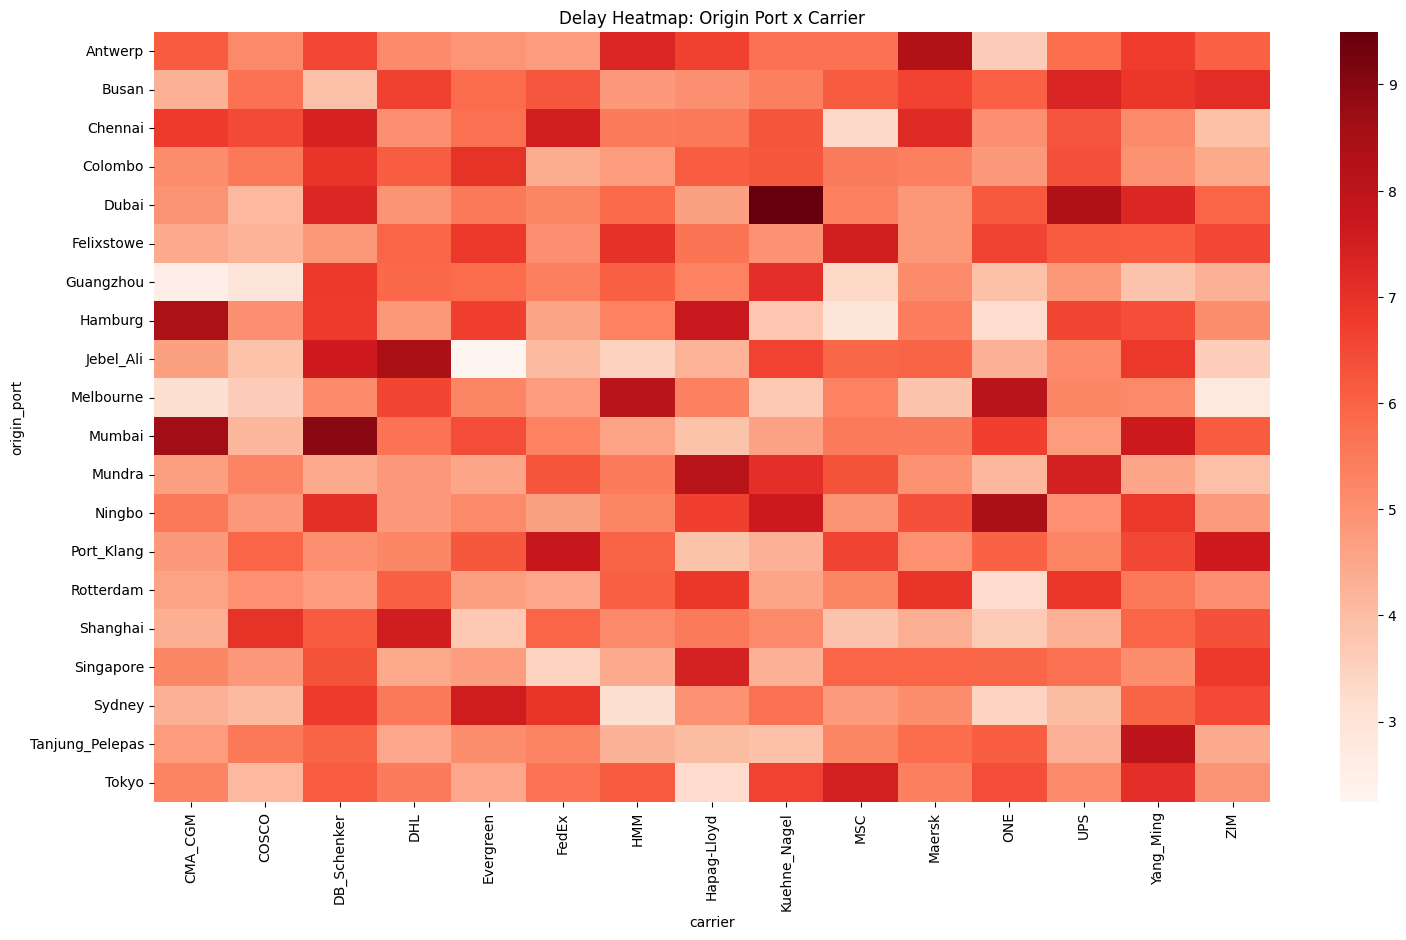

In [20]:
pivot=df.pivot_table(values='delay_hours',
                     index='origin_port',
                     columns='carrier',
                     aggfunc='mean')
plt.figure(figsize=(18,10))
sns.heatmap(pivot, cmap='Reds', annot=False)
plt.title('Delay Heatmap: Origin Port x Carrier')
plt.show()

In [21]:
pivot=df.pivot_table(values='delay_hours',
                     index='origin_port',
                     columns='carrier',
                     aggfunc='mean')
top_pairs =pivot.stack().sort_values(ascending=False).head(10)
top_pairs

origin_port  carrier     
Dubai        Kuehne_Nagel    9.494578
Mumbai       DB_Schenker     8.966667
             CMA_CGM         8.639161
Jebel_Ali    DHL             8.464671
Ningbo       ONE             8.460234
Hamburg      CMA_CGM         8.408537
Dubai        UPS             8.360000
Antwerp      Maersk          8.296250
Mundra       Hapag-Lloyd     8.146207
Melbourne    ONE             8.125843
dtype: float64

In [22]:
pivot_dest= df.pivot_table(values='delay_hours',
                           index='destination_port',
                           columns='carrier',
                           aggfunc='mean')
pivot_dest

carrier,CMA_CGM,COSCO,DB_Schenker,DHL,Evergreen,FedEx,HMM,Hapag-Lloyd,Kuehne_Nagel,MSC,Maersk,ONE,UPS,Yang_Ming,ZIM
destination_port,,,,,,,,,,,,,,,
Antwerp,6.221893,4.939444,6.564162,6.234483,7.760897,5.004698,3.331788,7.650000,6.527108,4.216667,5.520904,6.567785,7.222930,4.865089,9.118563
Baltimore,6.582955,5.436313,5.965497,5.582123,6.081522,5.844516,6.427848,4.753571,3.796364,6.242208,5.922857,3.321854,6.353801,8.456684,2.693293
Barcelona,4.646512,6.184865,7.181865,4.509554,5.878646,7.254286,5.453704,2.657233,3.396133,4.809195,7.085714,6.073973,5.407947,6.510303,5.353073
Bremen,4.206329,3.237654,6.355814,6.401258,6.801212,6.205442,7.159551,4.815854,3.596988,5.817610,5.501657,4.730601,6.316071,6.338562,5.421154
Dubai,6.155901,3.833742,6.127152,5.494969,4.903871,6.397452,4.821910,7.873034,6.481988,5.528571,5.607273,6.688554,7.029714,4.459551,4.801775
Felixstowe,5.995109,4.526943,4.442515,6.986154,4.772131,5.035758,3.443537,5.261039,7.100000,4.775316,5.638857,4.871505,5.322086,6.250307,6.654598
Genoa,7.421765,4.618072,5.593478,3.992949,4.832237,3.040252,6.435429,3.592228,3.489103,4.976074,6.652096,7.404878,3.101852,7.749351,8.461006
Hamburg,4.787654,5.513298,8.389583,6.873292,3.596894,3.681757,6.367380,4.552941,6.190132,4.250256,6.193296,4.719333,3.375301,4.330201,7.402778
Houston,5.572000,5.039884,5.483117,4.207018,6.422086,5.950000,3.317978,5.108176,5.708642,7.001695,8.343137,2.390798,4.003743,7.296815,5.683616


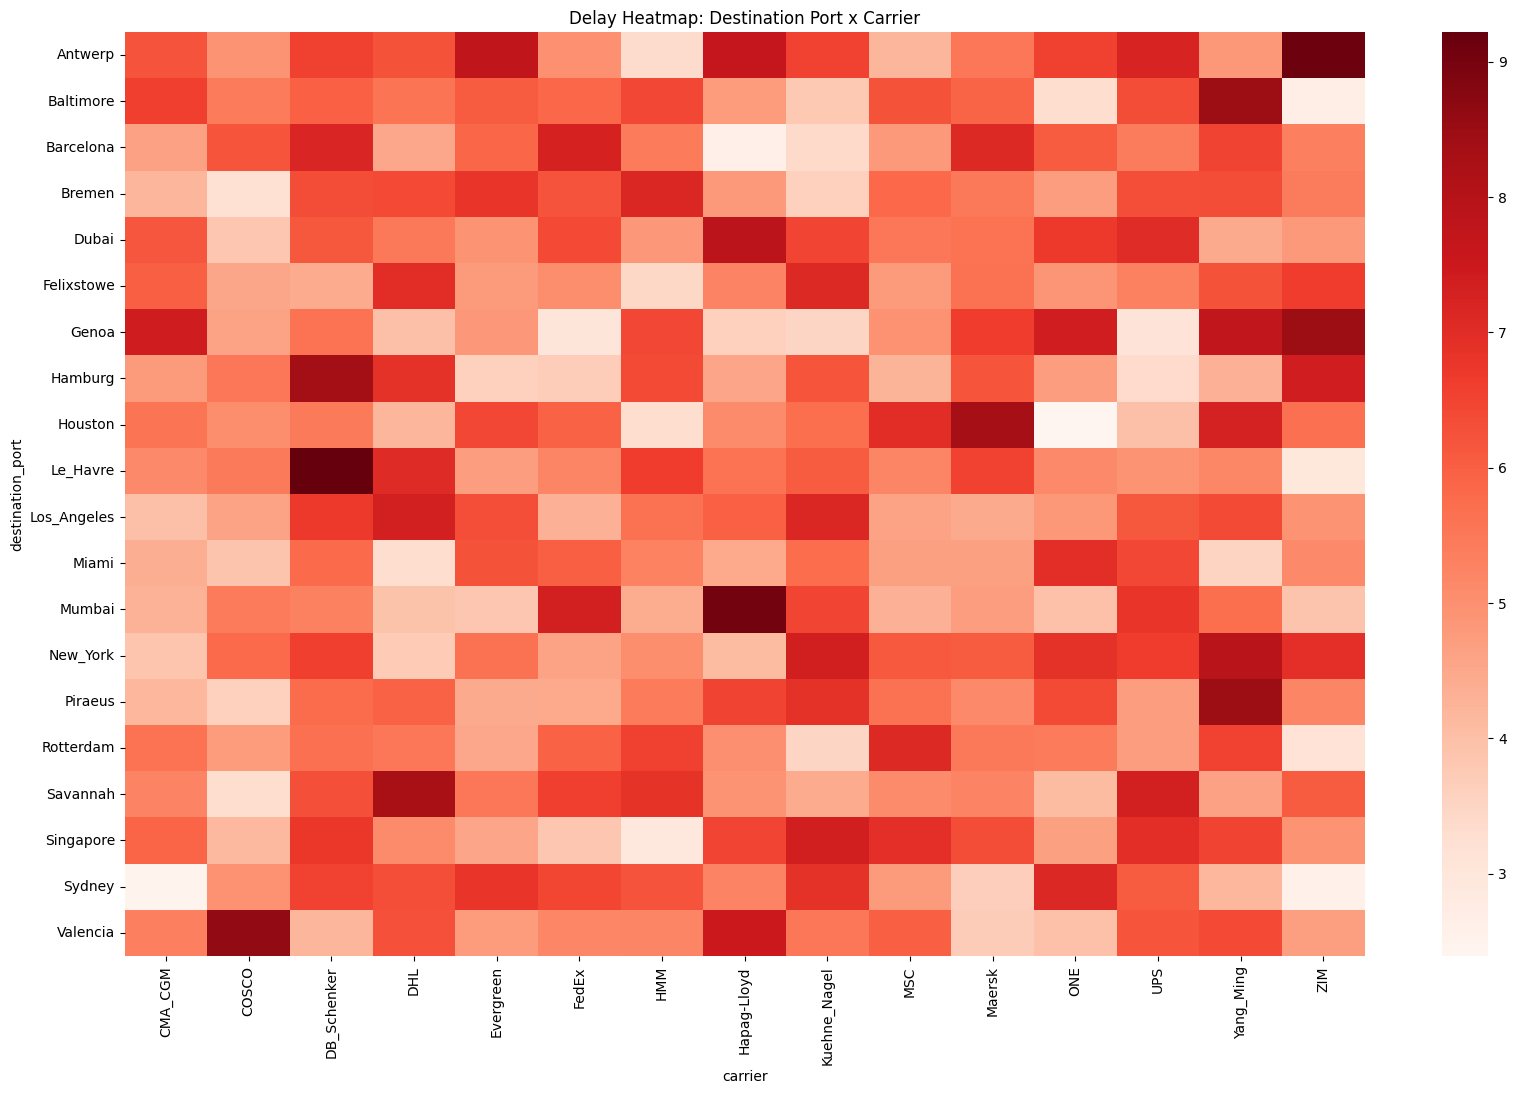

In [23]:
pivot_dest=df.pivot_table(values='delay_hours',
                     index='destination_port',
                     columns='carrier',
                     aggfunc='mean')
plt.figure(figsize=(20,12))
sns.heatmap(pivot_dest, cmap='Reds', annot=False)
plt.title('Delay Heatmap: Destination Port x Carrier')
plt.show()

In [24]:
pivot_dest=df.pivot_table(values='delay_hours',
                     index='destination_port',
                     columns='carrier',
                     aggfunc='mean')
top_pairs =pivot_dest.stack().sort_values(ascending=False).head(10)
top_pairs

destination_port  carrier    
Le_Havre          DB_Schenker    9.219231
Antwerp           ZIM            9.118563
Mumbai            Hapag-Lloyd    9.039881
Valencia          COSCO          8.624359
Genoa             ZIM            8.461006
Baltimore         Yang_Ming      8.456684
Piraeus           Yang_Ming      8.450000
Hamburg           DB_Schenker    8.389583
Houston           Maersk         8.343137
Savannah          DHL            8.308743
dtype: float64

In [25]:
df.groupby(['transport_mode'])['delay_hours'].mean().sort_values(ascending=False)

transport_mode
sea     5.580453
rail    5.550359
road    5.539070
air     5.345706
Name: delay_hours, dtype: float64

In [26]:
df.groupby(['origin_port','carrier','destination_port','transport_mode'])['delay_hours'].mean().sort_values(ascending=False).head(30)

origin_port      carrier       destination_port  transport_mode
Rotterdam        Maersk        Houston           rail              192.40
Busan            ZIM           Los_Angeles       air               168.80
Chennai          DB_Schenker   Mumbai            rail              147.70
Ningbo           FedEx         New_York          road              147.10
Felixstowe       HMM           Los_Angeles       rail              137.70
Mumbai           ONE           Le_Havre          rail              136.40
Melbourne        ONE           Los_Angeles       rail              133.50
Antwerp          Kuehne_Nagel  Antwerp           rail              131.20
Chennai          ONE           Antwerp           air               130.50
Rotterdam        UPS           Valencia          rail              129.90
Mumbai           Yang_Ming     Baltimore         rail              129.00
Rotterdam        CMA_CGM       Genoa             road              124.60
Colombo          Evergreen     Piraeus          

In [27]:
df['created_date']=pd.to_datetime(df['created_date'])
df['month']=df['created_date'].dt.month
df.groupby('month')['delay_hours'].mean().sort_values(ascending=False)

month
9     5.879446
6     5.782622
7     5.666113
2     5.623608
1     5.617304
11    5.588290
4     5.451601
10    5.440832
3     5.424147
5     5.344664
8     5.326018
12    5.249313
Name: delay_hours, dtype: float64

In [28]:
df['weekday'] =df['created_date'].dt.dayofweek
df.groupby('weekday')['delay_hours'].mean()

weekday
0    5.405621
1    5.716353
2    5.430278
3    5.425691
4    5.497661
5    5.421079
6    5.815626
Name: delay_hours, dtype: float64

In [29]:
df['month'] =df['created_date'].dt.month
df['season']=df['month'].map({
    12:'winter', 1:'winter', 2:'winter',
    3:'spring',4:'spring',5:'spring',
    6:'summer',7:'summer',8:'summer',
    9:'autumn',10:'autumn',11:'autumn'
})
df.groupby('season')['delay_hours'].mean()

season
autumn    5.637652
spring    5.406020
summer    5.585501
winter    5.492564
Name: delay_hours, dtype: float64

In [30]:
df['is_christmas'] =df['created_date'].dt.month.isin([12,1])
df.groupby('is_christmas')['delay_hours'].mean()

is_christmas
False    5.549706
True     5.431926
Name: delay_hours, dtype: float64

In [31]:
df['is_cny']=df['created_date'].dt.month==2
df.groupby('is_cny')['delay_hours'].mean()

is_cny
False    5.522075
True     5.623608
Name: delay_hours, dtype: float64

In [32]:
weakest=df.groupby(
    ['origin_port', 'carrier', 'destination_port', 'transport_mode']
)['delay_hours'].mean().sort_values(ascending=False).head(10)
weakest

origin_port  carrier       destination_port  transport_mode
Rotterdam    Maersk        Houston           rail              192.4
Busan        ZIM           Los_Angeles       air               168.8
Chennai      DB_Schenker   Mumbai            rail              147.7
Ningbo       FedEx         New_York          road              147.1
Felixstowe   HMM           Los_Angeles       rail              137.7
Mumbai       ONE           Le_Havre          rail              136.4
Melbourne    ONE           Los_Angeles       rail              133.5
Antwerp      Kuehne_Nagel  Antwerp           rail              131.2
Chennai      ONE           Antwerp           air               130.5
Rotterdam    UPS           Valencia          rail              129.9
Name: delay_hours, dtype: float64

In [34]:
# 1. Считаем общее количество строк в датасете
total_shipments = len(df)

# 2. Считаем, сколько было поездок с задержкой (больше 0 часов)
delayed_shipments = len(df[df['delay_hours'] > 0])

# 3. Находим процент опозданий
delay_percentage = (delayed_shipments / total_shipments) * 100

# 4. Выводим результат на экран
print(f"Общее количество поставок: {total_shipments} шт.")
print(f"Количество опозданий: {delayed_shipments} шт.")
print(f"Процент опозданий от общего числа: {delay_percentage:.2f}%")

Общее количество поставок: 50000 шт.
Количество опозданий: 11486 шт.
Процент опозданий от общего числа: 22.97%


In [35]:
# Отбираем только те строки, где задержка больше 0 часов
delayed_only = df[df['delay_hours'] > 0]

# Находим минимальное и максимальное значение
min_delay = delayed_only['delay_hours'].min()
max_delay = delayed_only['delay_hours'].max()

# Находим среднее время задержки для контекста
mean_delay = delayed_only['delay_hours'].mean()

print(f"Минимальное время опоздания: {min_delay:.1f} час(а)")
print(f"Максимальное время опоздания: {max_delay:.1f} час(а)")
print(f"Среднее время опоздания среди задержанных грузов: {mean_delay:.1f} час(а)")

Минимальное время опоздания: 0.1 час(а)
Максимальное время опоздания: 237.0 час(а)
Среднее время опоздания среди задержанных грузов: 24.1 час(а)
